## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [7]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [8]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [9]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [10]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


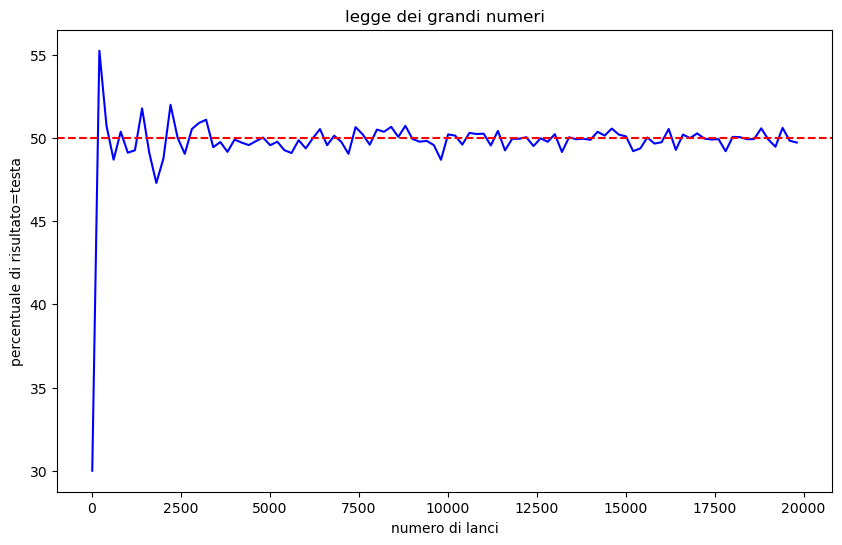

In [11]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

891
12
[0, 0, 0, 0, 0, 177, 0, 0, 0, 0, 687]
Non ci sono duplicati
Pclass
1    38.0
2    30.0
3    25.0
Name: Age, dtype: float64


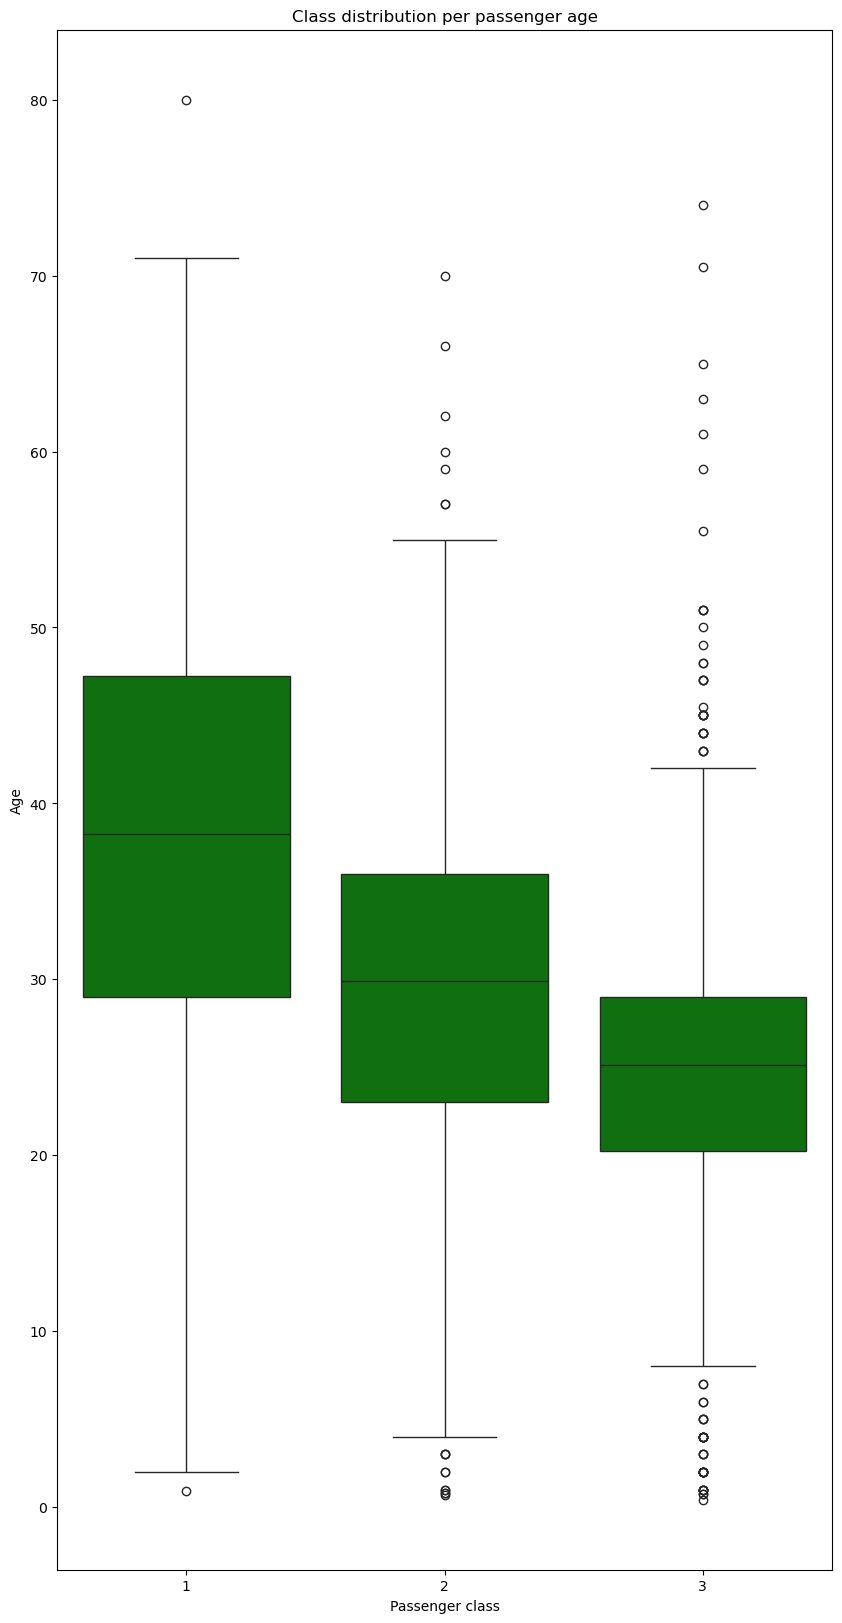

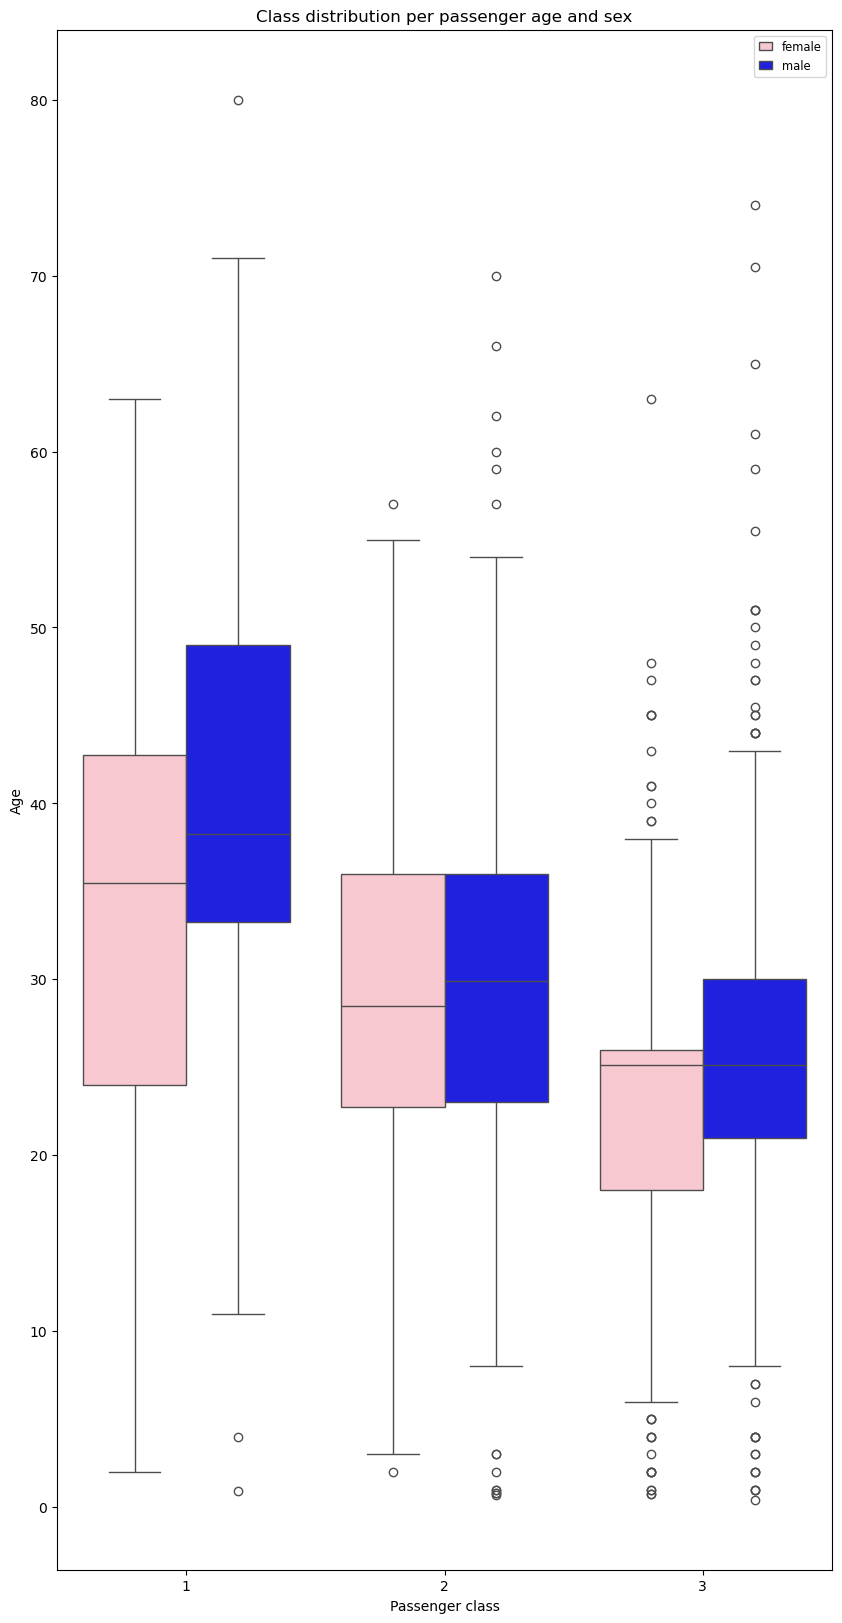

In [81]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

number_of_rows, number_of_columns = df.shape
print(number_of_rows)
print(number_of_columns)

nan_for_column = []
for i in range(0,(number_of_columns-1)):
    nan_for_column.append(int(df[df.columns[i]].isnull().sum()))
print(nan_for_column)

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode())

if int(df.duplicated().sum()) > 0:
    print("Ci sono duplicati")
else:
    print("Non ci sono duplicati")

mean_age_per_class = df.groupby("Pclass")["Age"].mean().round()
print(mean_age_per_class)
df["Age"] = df["Age"].fillna(df.groupby("Pclass")["Age"].transform("mean"))

plt.figure(figsize=(10,20))
sns.boxplot(data=df, x="Pclass", y="Age", color="green")
plt.title("Class distribution per passenger age")
plt.xlabel("Passenger class")
plt.show()

plt.figure(figsize=(10,20))
sns.boxplot(data=df, x="Pclass", y="Age", hue="Sex", palette=["pink","blue"])
plt.title("Class distribution per passenger age and sex")
plt.xlabel("Passenger class")
plt.legend(loc="upper right", fontsize="small", handlelength=1.2)
plt.show()


##### 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
0
0
species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal_length, dtype: float64
species
setosa        0.246
versicolor    1.326
virginica     2.026
Name: petal_width, dtype: float64


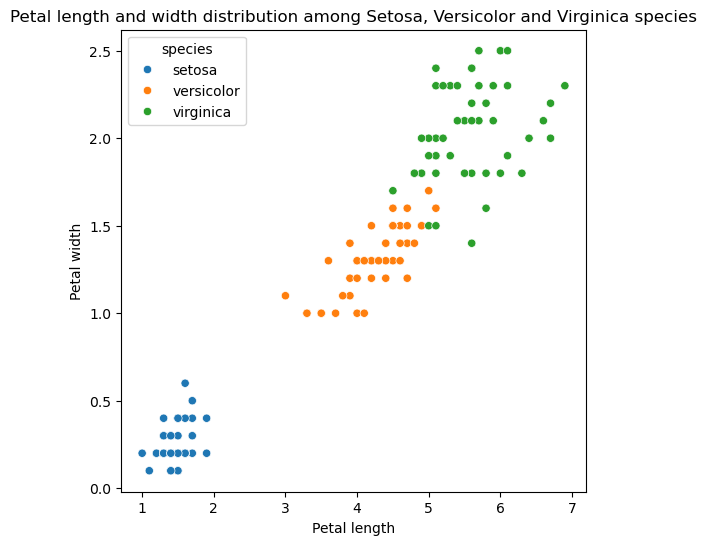

count    150.000000
mean       5.794067
std        4.712390
min        0.110000
25%        0.420000
50%        5.615000
75%        9.690000
max       15.870000
Name: petal_area, dtype: float64


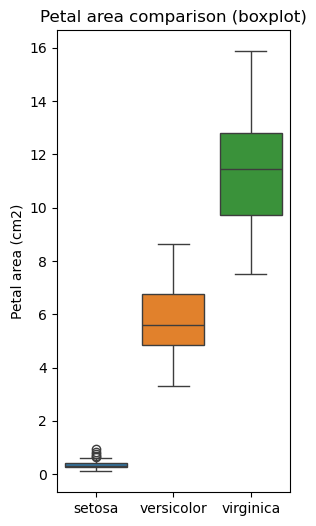

'\ndf_setosa_only = df[df["species"] == "setosa"]\nplt.figure(figsize=(1,3))\nsns.boxplot(data=df_setosa_only, x="species", y="petal_area")\nplt.xlabel("")\nplt.ylabel("Petal area (cm2)")\nplt.title("Specific Setosa boxplot")\nplt.show()\n\ndf_versicolor_only = df[df["species"] == "versicolor"]\nplt.figure(figsize=(1,3))\nsns.boxplot(data=df_versicolor_only, x="species", y="petal_area", color="orange")\nplt.xlabel("")\nplt.ylabel("Petal area (cm2)")\nplt.title("Specific Versicolor boxplot")\nplt.show()\n\ndf_virginica_only = df[df["species"] == "virginica"]\nplt.figure(figsize=(1,3))\nsns.boxplot(data=df_virginica_only, x="species", y="petal_area", color="lightgreen")\nplt.xlabel("")\nplt.ylabel("Petal area (cm2)")\nplt.title("Specific Virginica boxplot")\nplt.show()\n'

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

#Con un value_counts conto quante specie differenti ci sono nel dataframe
how_many_species = df["species"].value_counts()
print(how_many_species)

#Controllo di non avere valori nulli
print(df["petal_length"].isnull().sum())
print(df["petal_width"].isnull().sum())

#Calcolo le medie raggruppando le specie e utilizando la funzione mean sul valore specifico
mean_petal_length_per_species = df.groupby("species")["petal_length"].mean()
print(mean_petal_length_per_species)
mean_petal_width_per_species = df.groupby("species")["petal_width"].mean()
print(mean_petal_width_per_species)

#Creo lo scatterplot ponendo come x la lunghezza e y la larghezza. Utilizzo hue per differenziare le tre specie
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species")
plt.title("Petal length and width distribution among Setosa, Versicolor and Virginica species")
plt.ylabel("Petal width")
plt.xlabel("Petal length")
plt.show()

#Creo una nuova sezione del dataframe facendo il prodotto di lunghezza e larghezza
df["petal_area"] = df["petal_length"] * df["petal_width"]
print(df["petal_area"].describe())

#Creo un boxplot con l'area delle tre specie
plt.figure(figsize=(3,6))
sns.boxplot(data=df, y="petal_area", x="species", hue="species")
plt.xlabel("")
plt.ylabel("Petal area (cm2)")
plt.title("Petal area comparison (boxplot)")
plt.show()

###############################################################
#                  Boxplot specie specifico                   #
###############################################################
# Non è richiesto ma, essendo il boxplot della setosa molto   #
# schiacciato ( le aree dei petali sono molto piccole )       #
# e avendo molti outliers, creo dei nuovi dataframes          #
# contenenti ognuno solo i valori della specie corrispondente #
# usando una maschera booleana ( controllando ogni riga del   #
# df contenente la specie, se presente quella specificata     #
# restituisce true, altrimenti false ) e reinserendola nel df #
# seleziono solo le specie specifiche. Così facendo si può    #
# notare come gli outliers della setosa fossero molti a causa #
# dello sfasamento nelle misurazioni causato dalla virginica. #
# Un altro modo per visualizzare ciò sarebbe stato utilizzare #
# una scala logaritmica, cambiando così la percezione della   #
# grandezza reale dei petali delle tre specie.                #
###############################################################
"""
df_setosa_only = df[df["species"] == "setosa"]
plt.figure(figsize=(1,3))
sns.boxplot(data=df_setosa_only, x="species", y="petal_area")
plt.xlabel("")
plt.ylabel("Petal area (cm2)")
plt.title("Specific Setosa boxplot")
plt.show()

df_versicolor_only = df[df["species"] == "versicolor"]
plt.figure(figsize=(1,3))
sns.boxplot(data=df_versicolor_only, x="species", y="petal_area", color="orange")
plt.xlabel("")
plt.ylabel("Petal area (cm2)")
plt.title("Specific Versicolor boxplot")
plt.show()

df_virginica_only = df[df["species"] == "virginica"]
plt.figure(figsize=(1,3))
sns.boxplot(data=df_virginica_only, x="species", y="petal_area", color="lightgreen")
plt.xlabel("")
plt.ylabel("Petal area (cm2)")
plt.title("Specific Virginica boxplot")
plt.show()
"""